# Archetypes and Insights

Identify distinct patterns of healthcare inequality by combining population demand and effective access.

This notebook focuses on interpretation rather than computation.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    FILES,
    ensure_project_dirs,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Nairobi
BBOX: {'lon_min': 36.6, 'lat_min': -1.5, 'lon_max': 37.1, 'lat_max': -1.1}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/hrsl_kenya.tif


In [2]:
effective_access = gpd.read_parquet(FILES["effective_access"])

print("Grid cells:", len(effective_access))
effective_access.head()

Grid cells: 2520


,grid_id,geometry,cell_area_m2,cell_area_km2,population,population_density_km2,centroid,nearest_node,nearest_hospital_distance_m,multi_access_score,effective_access_score,population_norm,effective_access_norm,inequality_score
0,g_00000,"POLYGON ((233951.523 9835052.618, 233952.606 9...",1000000.0,1.0,0.000000,0.000000,POINT (233451.994 9834555.35),6285881207,18919.701825,8.140083e-07,8.532563e-12,0.000000,0.000171,0.000000
1,g_00001,"POLYGON ((233950.447 9836046.069, 233951.523 9...",1000000.0,1.0,13.913320,13.913320,POINT (233450.912 9835548.801),6337914595,19302.596780,7.939942e-07,8.338189e-12,0.000136,0.000167,0.000136
2,g_00002,"POLYGON ((233949.378 9837039.523, 233950.447 9...",1000000.0,1.0,13.913320,13.913320,POINT (233449.838 9836542.257),6337914595,19302.596780,7.939942e-07,8.338189e-12,0.000136,0.000167,0.000136
3,g_00003,"POLYGON ((233948.314 9838032.982, 233949.378 9...",1000000.0,1.0,16.695984,16.695984,POINT (233448.769 9837535.717),6337903905,21495.756410,7.207551e-07,7.744985e-12,0.000164,0.000155,0.000164
4,g_00004,"POLYGON ((233947.258 9839026.444, 233948.314 9...",1000000.0,1.0,91.827912,91.827912,POINT (233447.707 9838529.18),6300726455,20307.217036,7.750054e-07,8.290689e-12,0.000899,0.000166,0.000899


In [3]:
# Use percentiles instead of hard thresholds
pop_high = effective_access["population_norm"].quantile(0.75)
access_low = effective_access["effective_access_norm"].quantile(0.25)

print("High population threshold:", pop_high)
print("Low access threshold:", access_low)

High population threshold: 0.022766890621787345
Low access threshold: 0.0007015470803259117


In [16]:
def classify(row):
    if row["population_norm"] >= pop_high and row["effective_access_norm"] <= access_low:
        return "High Demand - Low Access"
    elif row["population_norm"] >= pop_high:
        return "High Demand - Stressed Access"
    elif row["effective_access_norm"] <= access_low:
        return "Low Demand - Low Access"
    else:
        return "Moderate / Balanced"

effective_access["archetype"] = effective_access.apply(classify, axis=1)

effective_access["archetype"].value_counts()

archetype
Moderate / Balanced              1269
Low Demand - Low Access           621
High Demand - Stressed Access     619
High Demand - Low Access           11
Name: count, dtype: int64

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/09_archetypes_map.png


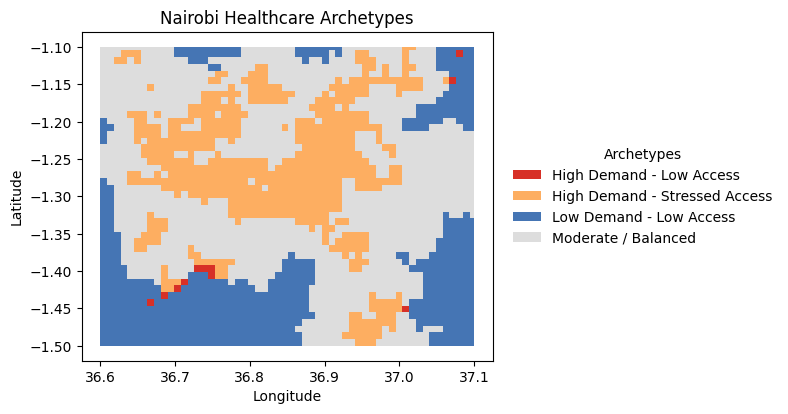

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 8))

plot_df = effective_access.to_crs(CRS_WGS84)

colors = {
    "High Demand - Low Access": "#d73027",
    "High Demand - Stressed Access": "#fdae61",
    "Low Demand - Low Access": "#4575b4",
    "Moderate / Balanced": "#dddddd"
}

for archetype, color in colors.items():
    subset = plot_df[plot_df["archetype"] == archetype]
    subset.plot(ax=ax, color=color, linewidth=0)

legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=archetype)
    for archetype, color in colors.items()
]

ax.legend(
    handles=legend_handles,
    title="Archetypes",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.set_title(f"{CITY_NAME} Healthcare Archetypes")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.subplots_adjust(right=0.75)
plt.tight_layout()

savefig(fig, "09_archetypes_map.png")
plt.show()

Critical zones count: 11


,grid_id,geometry,cell_area_m2,cell_area_km2,population,population_density_km2,centroid,nearest_node,nearest_hospital_distance_m,multi_access_score,effective_access_score,population_norm,effective_access_norm,inequality_score,archetype
321,g_00321,"POLYGON ((239947.046 9840026.162, 239946.026 9...",1000000.0,1.0,2361.978588,2361.978588,POINT (240446.595 9840523.391),6288815149,7670.743391,0.000002,2.265325e-11,0.023134,0.000453,0.023124,High Demand - Low Access
412,g_00412,"POLYGON ((241946.261 9841021.633, 241945.255 9...",1000000.0,1.0,2538.020818,2538.020818,POINT (242445.813 9841518.85),3546691200,4920.832127,0.000004,3.453900e-11,0.024859,0.000691,0.024842,High Demand - Low Access
503,g_00503,"POLYGON ((243945.473 9842017.066, 243944.481 9...",1000000.0,1.0,2391.154740,2391.154740,POINT (244445.027 9842514.272),6295520694,5275.411981,0.000004,3.237531e-11,0.023420,0.000647,0.023405,High Demand - Low Access
549,g_00549,"POLYGON ((244944.584 9843011.473, 244943.603 9...",1000000.0,1.0,2647.915485,2647.915485,POINT (245444.142 9843508.672),6295628419,5194.089161,0.000004,3.410359e-11,0.025935,0.000682,0.025917,High Demand - Low Access
641,g_00641,"POLYGON ((246942.83 9845000.249, 246941.868 98...",1000000.0,1.0,7607.342034,7607.342034,POINT (247442.396 9845497.436),8478050498,6698.587271,0.000003,3.203936e-11,0.074510,0.000641,0.074463,High Demand - Low Access


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/09_critical_zones.png


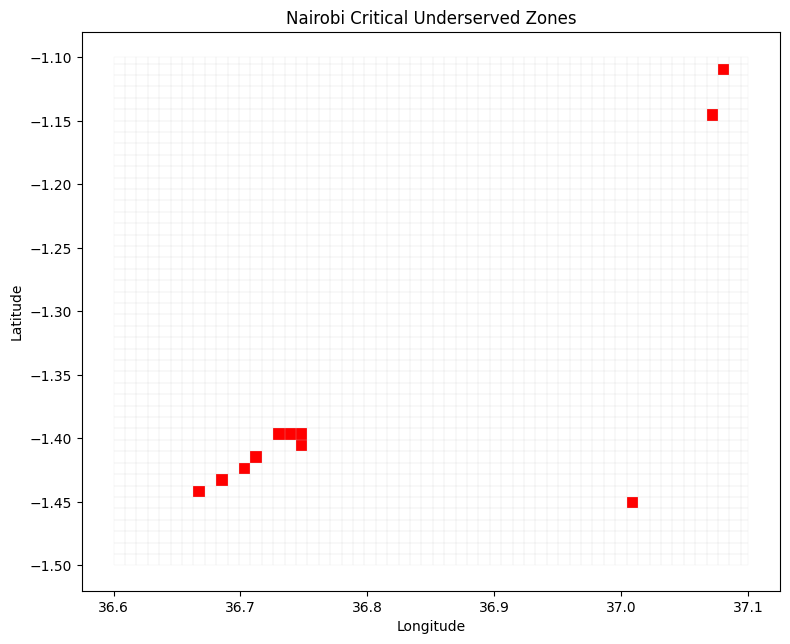

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

plot_df.boundary.plot(ax=ax, color="lightgray", linewidth=0.1)

critical_wgs84 = critical.to_crs(CRS_WGS84)
critical_wgs84.plot(ax=ax, color="red", linewidth=0)

ax.set_title(f"{CITY_NAME} Critical Underserved Zones")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "09_critical_zones.png")
plt.show()

In [8]:
summary = effective_access.groupby("archetype").agg(
    count=("grid_id", "count"),
    avg_population=("population", "mean"),
    avg_access=("effective_access_norm", "mean"),
    avg_inequality=("inequality_score", "mean")
).reset_index()

summary

,archetype,count,avg_population,avg_access,avg_inequality
0,High Demand - Low Access,11,6024.398607,0.000596,0.058970
1,High Demand - Moderate Access,619,10484.463875,0.028420,0.099196
2,Low Demand - Low Access,621,217.169235,0.000408,0.002126
3,Moderate / Balanced,1269,661.215787,0.005692,0.006430


## Key Insights

1. Healthcare inequality is concentrated in specific urban clusters rather than being uniformly distributed.

2. High-demand regions with relatively low effective access form the most critical underserved zones.

3. Proximity to hospitals does not guarantee access — hospital burden significantly reduces effective accessibility.

4. Some peripheral areas show low access but also low demand, suggesting different prioritization compared to dense urban hotspots.

5. The system exhibits structural imbalance: demand concentrates faster than accessible capacity.

## Interpretation

The results indicate that healthcare inequality emerges from the interaction of three factors:
- population density
- spatial accessibility
- hospital load

Rather than a lack of hospitals, the issue is a mismatch between where people are and how healthcare resources are effectively distributed under load.

In [18]:
best_served_threshold = effective_access["multi_access_score"].quantile(0.80)
high_inequality_threshold = effective_access["inequality_score"].quantile(0.80)

best_served = effective_access["multi_access_score"] >= best_served_threshold
high_inequality = effective_access["inequality_score"] >= high_inequality_threshold

overlap_count = (best_served & high_inequality).sum()
best_served_count = best_served.sum()

overlap_pct = 100 * overlap_count / best_served_count

print("Best-served cells:", best_served_count)
print("Overlap with high-inequality cells:", overlap_count)
print("Percent overlap:", overlap_pct)

Best-served cells: 504
Overlap with high-inequality cells: 305
Percent overlap: 60.51587301587302


In [19]:
band = effective_access[
    (effective_access["nearest_hospital_distance_m"] >= 4000) &
    (effective_access["nearest_hospital_distance_m"] <= 5000)
].copy()

band = band.sort_values("effective_access_score")

print(band[[
    "grid_id",
    "nearest_hospital_distance_m",
    "population",
    "effective_access_score",
    "inequality_score"
]].head(5))

print(band[[
    "grid_id",
    "nearest_hospital_distance_m",
    "population",
    "effective_access_score",
    "inequality_score"
]].tail(5))

     grid_id  nearest_hospital_distance_m   population  \
412  g_00412                  4920.832127  2538.020818   
368  g_00368                  4881.399433  2201.872680   
458  g_00458                  4607.094936  3050.522086   
504  g_00504                  4379.368965  4651.604044   
506  g_00506                  4380.529343  1214.673964   

     effective_access_score  inequality_score  
412            3.453900e-11          0.024842  
368            3.502493e-11          0.021551  
458            3.677695e-11          0.029856  
504            3.858953e-11          0.045525  
506            3.912690e-11          0.011888  
      grid_id  nearest_hospital_distance_m   population  \
1199  g_01199                  4057.547328    63.873808   
883   g_00883                  4700.959853  2096.660769   
838   g_00838                  4693.145895  1327.776324   
1654  g_01654                  4682.892518  9838.887310   
1745  g_01745                  4060.911655     0.000000   

      ef

In [20]:
pop_threshold = effective_access["population"].quantile(0.90)

effective_access["dense_group"] = np.where(
    effective_access["population"] >= pop_threshold,
    "Top 10% population",
    "Other cells"
)

summary = effective_access.groupby("dense_group").agg(
    mean_nearest_distance_m=("nearest_hospital_distance_m", "mean"),
    mean_effective_access=("effective_access_score", "mean"),
    mean_inequality=("inequality_score", "mean"),
    cell_count=("grid_id", "count")
)

print(summary)

                    mean_nearest_distance_m  mean_effective_access  \
dense_group                                                          
Other cells                     8081.043769           3.570115e-10   
Top 10% population              1909.736038           1.762722e-09   

                    mean_inequality  cell_count  
dense_group                                      
Other cells                0.010094        2268  
Top 10% population         0.193006         252  
